A notebook to run the data from the March 2024 flights through NF2FF, without having to reinterpolate as before

In [3]:
## import statements:
import numpy as np
from matplotlib.pyplot import *
from numpy.fft import fft2
from numpy.fft import ifft2
from numpy.fft import fftshift
from numpy.fft import ifftshift
from scipy.interpolate import griddata
import beamcals.fitting_utils as fu

import pandas
from matplotlib.colors import LogNorm

from scipy.interpolate import RectBivariateSpline

import NF2FF as nf

import pykrige.kriging_tools as kt
from pykrige.ok import OrdinaryKriging

In [4]:
font = {'family' : 'normal',
        'size'   : 12}

matplotlib.rc('font', **font)

In [5]:
dat=np.load("../cplxEfield_04112024.npz")
for key in dat.keys():
    print(key)

cplxEfieldNS_interped
cplxEfieldEW_interped
x
y
freq


In [6]:
NF_EW_Complex=dat['cplxEfieldEW_interped']
NF_NS_Complex=dat['cplxEfieldNS_interped']
NF_x = dat['x']
NF_y = dat['y']
freq = dat['freq']

print(NF_EW_Complex.shape)
print(NF_NS_Complex.shape)
print(NF_x.shape)
print(NF_y.shape)

(53, 53)
(53, 53)
(53, 53)
(53, 53)


Can't use the RegularGridding function for this because of how the data is, so will make the gridding myself in the next cell(s)

In [7]:
NF_x_vector = NF_x[:,0]
NF_y_vector = NF_y[0,:]

print(NF_x_vector)
print(NF_y_vector)

[-3.90996241e+00 -3.75958647e+00 -3.60921053e+00 -3.45883459e+00
 -3.30845865e+00 -3.15808271e+00 -3.00770677e+00 -2.85733083e+00
 -2.70695489e+00 -2.55657895e+00 -2.40620301e+00 -2.25582707e+00
 -2.10545113e+00 -1.95507519e+00 -1.80469925e+00 -1.65432331e+00
 -1.50394737e+00 -1.35357143e+00 -1.20319549e+00 -1.05281955e+00
 -9.02443609e-01 -7.52067669e-01 -6.01691729e-01 -4.51315789e-01
 -3.00939850e-01 -1.50563910e-01 -1.87969925e-04  1.50187970e-01
  3.00563910e-01  4.50939850e-01  6.01315789e-01  7.51691729e-01
  9.02067669e-01  1.05244361e+00  1.20281955e+00  1.35319549e+00
  1.50357143e+00  1.65394737e+00  1.80432331e+00  1.95469925e+00
  2.10507519e+00  2.25545113e+00  2.40582707e+00  2.55620301e+00
  2.70657895e+00  2.85695489e+00  3.00733083e+00  3.15770677e+00
  3.30808271e+00  3.45845865e+00  3.60883459e+00  3.75921053e+00
  3.90958647e+00]
[-3.90996241e+00 -3.75958647e+00 -3.60921053e+00 -3.45883459e+00
 -3.30845865e+00 -3.15808271e+00 -3.00770677e+00 -2.85733083e+00
 -2.706

In [8]:
# checking the spacing between points in the x and y vectors is consistent
print(NF_x_vector[1] - NF_x_vector[0])
print(NF_x_vector[2] - NF_x_vector[1])
print(NF_x_vector[51] - NF_x_vector[50])
print(NF_y_vector[1] - NF_y_vector[0])
print(NF_y_vector[2] - NF_y_vector[1])
print(NF_y_vector[51] - NF_y_vector[50])

0.15037593984962427
0.15037593984962427
0.15037593984962427
0.15037593984962427
0.15037593984962427
0.15037593984962427


In [108]:
# making the gridding

M=NF_EW_Complex.shape[0]
N=NF_EW_Complex.shape[1]
dx = NF_x_vector[1] - NF_x_vector[0]
dy = NF_y_vector[1] - NF_y_vector[0]
dtheta = 0.01 # before was at 0.05
dphi = 0.01

# setting up k-space, theta, phi grids
# See equations (16-13a) and (16-13b) in Balanis
# Zero padding is used to increase the resolution of the plane wave spectral domain.
MI=4*M;#2^(ceil(log2(M))+1);
NI=4*N;#2^(ceil(log2(N))+1);
m=np.linspace(-MI/2,MI/2-1,MI);
n=np.linspace(-NI/2,NI/2-1,NI)
k_X_Rectangular=(2*np.pi*m)/(MI*dx);
k_Y_Rectangular=(2*np.pi*n)/(NI*dy);
theta=np.arange(0,np.pi/2+dtheta,dtheta);
phi=np.arange(0,2*np.pi+dphi,dphi);
print(len(theta))
print(len(phi))
[theta,phi]=np.meshgrid(theta,phi);
print(theta.shape)

159
630
(630, 159)


In [10]:
print(freq)

670.703125


In [11]:
# frequency stuff--frequency comes in Hertz
k0 = nf.Calculate_k0(freq*(10**6))
nyquist_m = nf.NyquistSampling(freq*(10**6))

print(nyquist_m)

0.22349117428072218


<ipython-input-14-edec4fa81f14>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm1 = ax[0][0].pcolormesh(x,y,np.abs(NF_EW_Complex))
<ipython-input-14-edec4fa81f14>:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm2 = ax[0][1].pcolormesh(x,y,np.abs(NF_NS_Complex))
<ipython-input-14-edec4fa81f14>:12: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadril

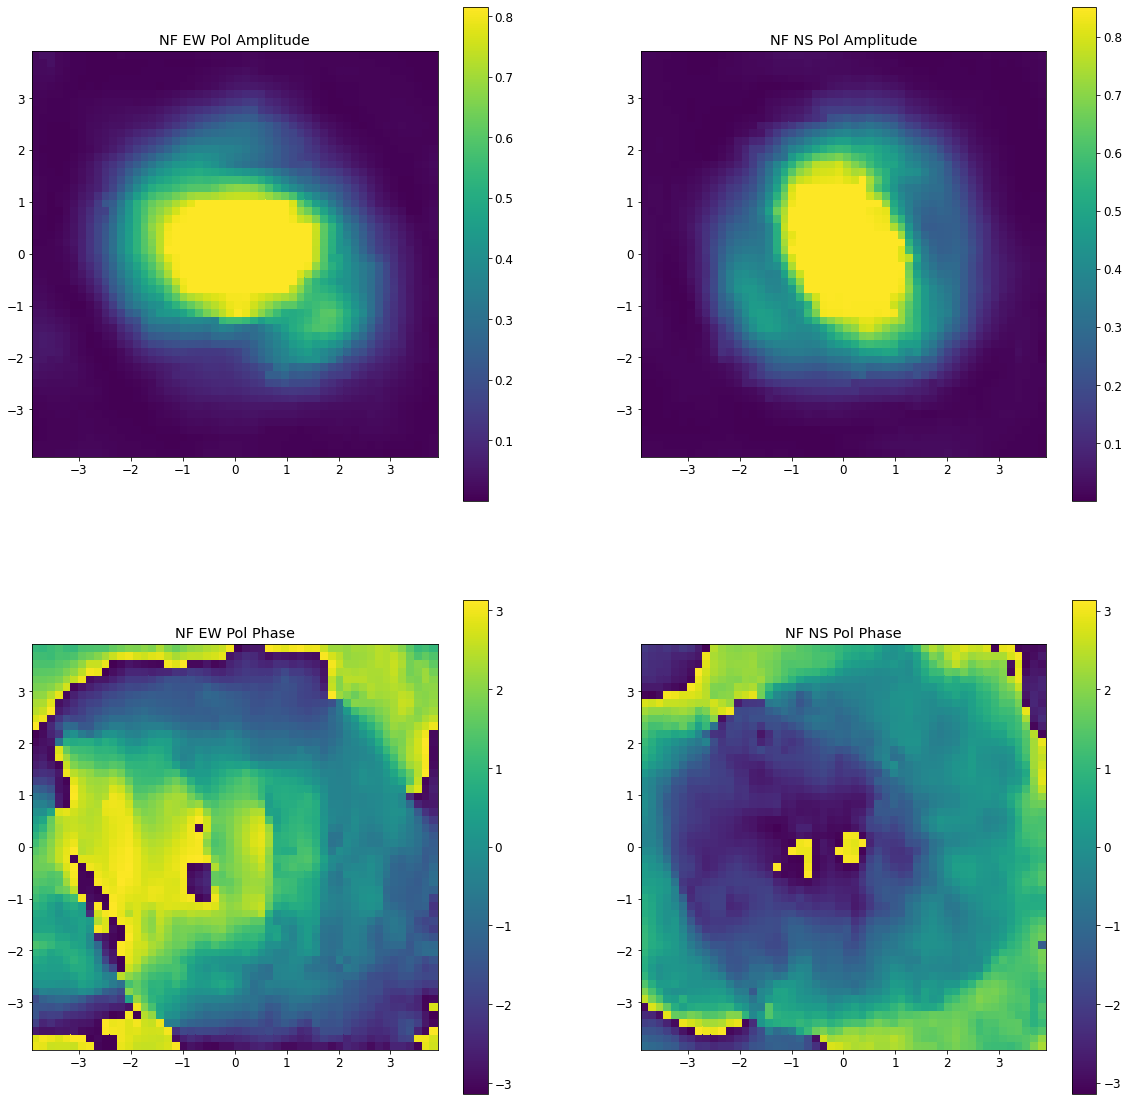

In [14]:
# [x_grid,y_grid]=np.meshgrid(x,y)

x=NF_x
y=NF_y
[x_grid,y_grid]=np.meshgrid(x,y)

fig,ax=subplots(2,2,figsize=(20,20))
pcm1 = ax[0][0].pcolormesh(x,y,np.abs(NF_EW_Complex))
ax[0][0].set_title('NF EW Pol Amplitude')
pcm2 = ax[0][1].pcolormesh(x,y,np.abs(NF_NS_Complex))
ax[0][1].set_title('NF NS Pol Amplitude')
pcm3 = ax[1][0].pcolormesh(x,y,np.angle(NF_EW_Complex))
ax[1][0].set_title('NF EW Pol Phase')
pcm4 = ax[1][1].pcolormesh(x,y,np.angle(NF_NS_Complex))
ax[1][1].set_title('NF NS Pol Phase')
pcms = [[pcm1, pcm2], [pcm3, pcm4]]
for i, axis_set in enumerate(ax):
    for i2, a in enumerate(axis_set):
        a.set_aspect('equal')
        colorbar(mappable=pcms[i][i2],ax=a)

<ipython-input-15-8d600d438d11>:2: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm1 = ax[0][0].pcolormesh(x,y,(NF_EW_Complex.real))
<ipython-input-15-8d600d438d11>:4: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm2 = ax[0][1].pcolormesh(x,y,(NF_EW_Complex.imag))
<ipython-input-15-8d600d438d11>:6: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilater

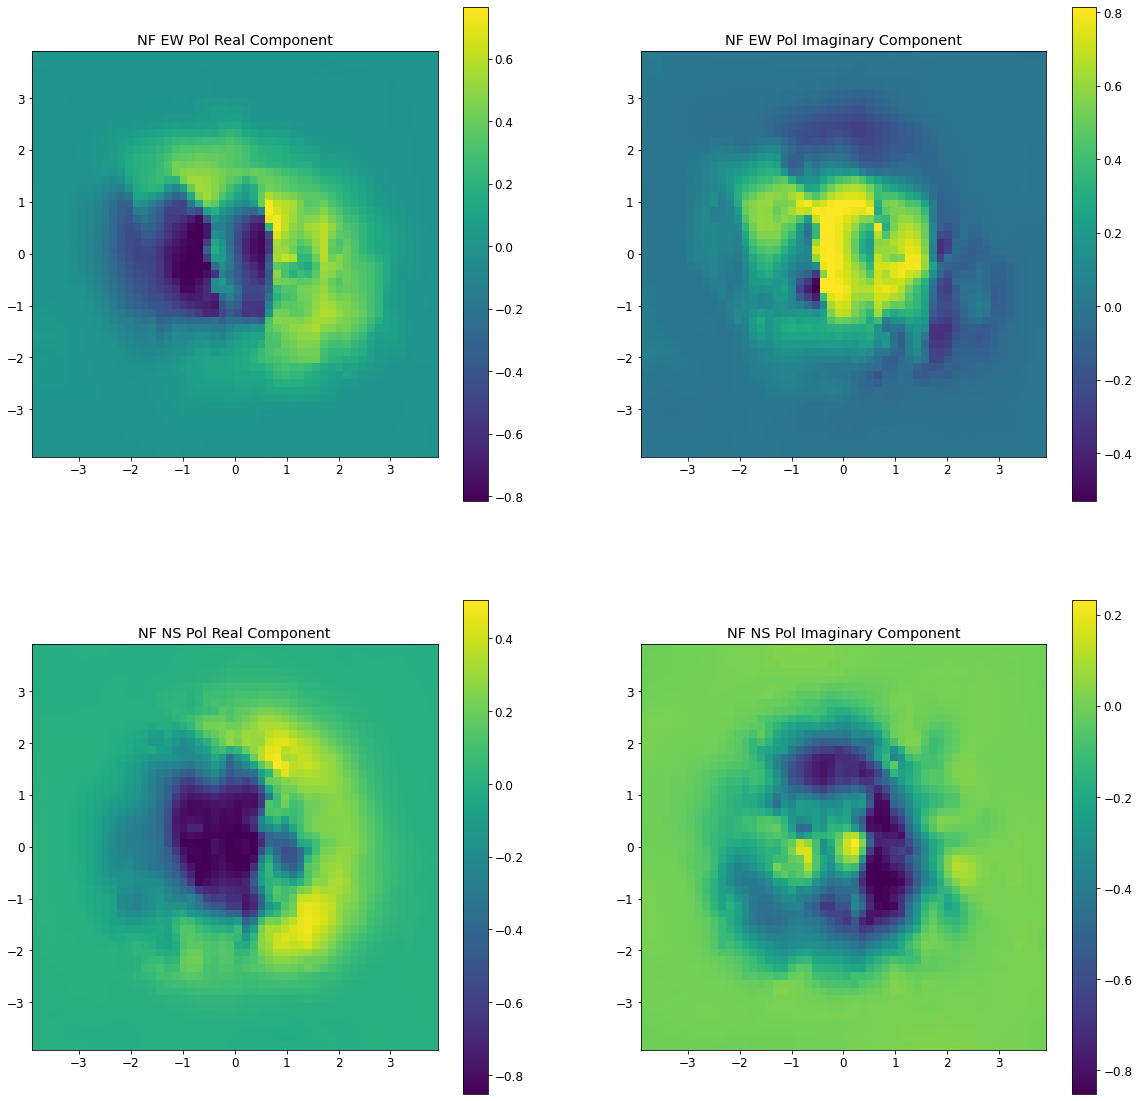

In [15]:
fig,ax=subplots(2,2,figsize=(20,20))
pcm1 = ax[0][0].pcolormesh(x,y,(NF_EW_Complex.real))
ax[0][0].set_title('NF EW Pol Real Component')
pcm2 = ax[0][1].pcolormesh(x,y,(NF_EW_Complex.imag))
ax[0][1].set_title('NF EW Pol Imaginary Component')
pcm3 = ax[1][0].pcolormesh(x,y,(NF_NS_Complex.real))
ax[1][0].set_title('NF NS Pol Real Component')
pcm4 = ax[1][1].pcolormesh(x,y,(NF_NS_Complex.imag))
ax[1][1].set_title('NF NS Pol Imaginary Component')
pcms = [[pcm1, pcm2], [pcm3, pcm4]]
for i, axis_set in enumerate(ax):
    for i2, a in enumerate(axis_set):
        a.set_aspect('equal')
        colorbar(mappable=pcms[i][i2],ax=a)

In [12]:
# counting the number of NaNs
print(np.count_nonzero(np.isnan(NF_EW_Complex)))
print(np.count_nonzero(np.isnan(NF_NS_Complex)))
print(NF_EW_Complex.shape)
print(6356/86/86)
print(53*53)

0
0
(53, 53)
0.8593834505137913
2809


## Constructing the Apodization Function

### Gaussian

In [149]:
# creating a bunch of different apodizations
list_of_intervals = [1.5, 3.75, 5, 6]
x_range = (np.max(NF_x) - np.min(NF_x))/2
print(x_range)
sigmas = x_range/list_of_intervals
print(sigmas)
Gaussian_windows = np.empty((len(sigmas), len(NF_x_vector), len(NF_y_vector)))
for i, sigma in enumerate(sigmas):
    P = [1, 0, sigma, 0, sigma, 0]
    Gaussian_windows[i, :, :] = fu.Gauss_2d_LC_func(P, NF_x, NF_y)

3.909774436090225
[2.60651629 1.04260652 0.78195489 0.65162907]


In [150]:
Gaussian_windows.shape

(4, 53, 53)

<ipython-input-151-15a42df5bd0e>:4: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm=ax[i].pcolormesh(NF_x, NF_y, Gaussian_window)


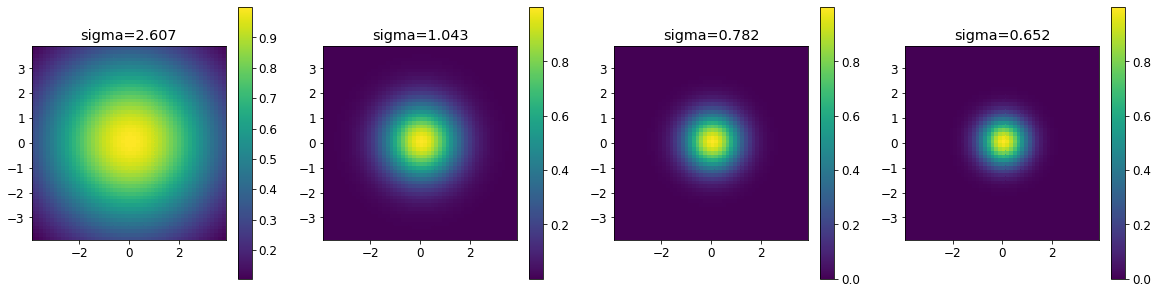

In [151]:
# checking by plotting
fig, ax = subplots(1, 4, figsize=(20, 10))
for i, Gaussian_window in enumerate(Gaussian_windows):
    pcm=ax[i].pcolormesh(NF_x, NF_y, Gaussian_window)
    ax[i].set_aspect('equal')
    colorbar(mappable=pcm, ax=ax[i],shrink=0.5)
    ax[i].set_title(f"sigma={sigmas[i]:.3f}")

In [152]:
# set the apodization function
apodizers = Gaussian_windows

### Modulating the signal

In [153]:
NF_EW_apodized = NF_EW_Complex*apodizers
NF_NS_apodized = NF_NS_Complex*apodizers

In [154]:
NF_EW_apodized.shape

(4, 53, 53)

<ipython-input-155-7ce1a254c73c>:9: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm1=ax[0][i].pcolormesh(x, y, np.abs(EW_apodized))
<ipython-input-155-7ce1a254c73c>:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm2=ax[1][i].pcolormesh(x, y, np.angle(EW_apodized))
<ipython-input-155-7ce1a254c73c>:17: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadri

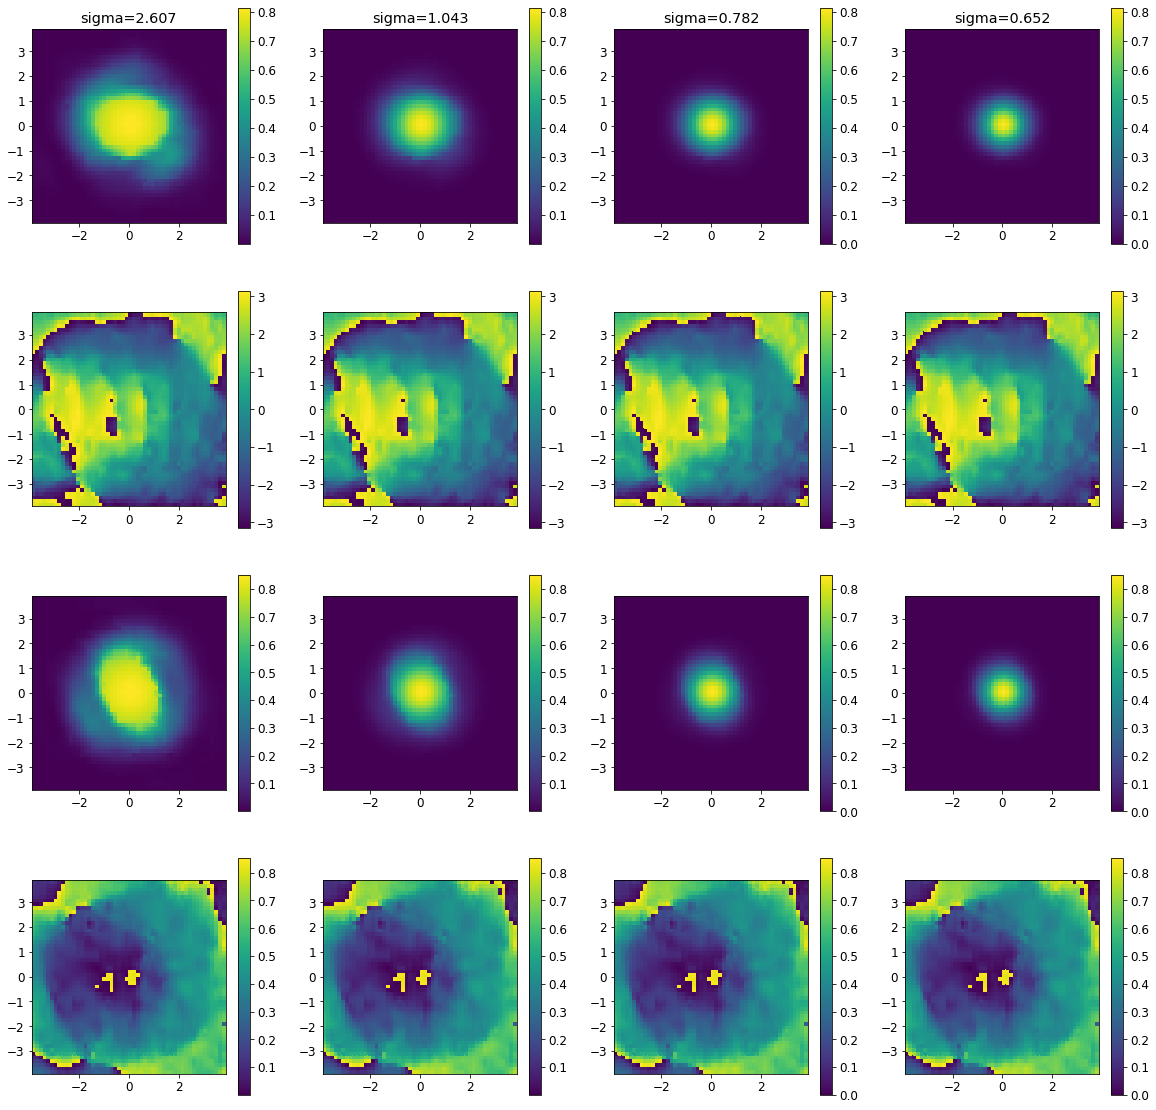

In [155]:
# [x_grid,y_grid]=np.meshgrid(x,y)

x=NF_x
y=NF_y
[x_grid,y_grid]=np.meshgrid(x,y)

fig,ax=subplots(4,4,figsize=(20,20))
for i, EW_apodized in enumerate(NF_EW_apodized):
    pcm1=ax[0][i].pcolormesh(x, y, np.abs(EW_apodized))
    pcm2=ax[1][i].pcolormesh(x, y, np.angle(EW_apodized))
    ax[0][i].set_aspect('equal')
    ax[1][i].set_aspect('equal')
    colorbar(mappable=pcm1, ax=ax[0][i])
    colorbar(mappable=pcm2, ax=ax[1][i])
    ax[0][i].set_title(f"sigma={sigmas[i]:.3f}")
for i, NS_apodized in enumerate(NF_NS_apodized):
    pcm1=ax[2][i].pcolormesh(x, y, np.abs(NS_apodized))
    pcm2=ax[3][i].pcolormesh(x, y, np.angle(NS_apodized))
    ax[2][i].set_aspect('equal')
    ax[3][i].set_aspect('equal')
    colorbar(mappable=pcm1, ax=ax[2][i])
    colorbar(mappable=pcm1, ax=ax[3][i])

In [156]:
# plotting a cross-section of amplitudes to make sure they all really go to 0
slice_index = np.where((NF_x_vector<0.1) & (NF_x_vector > -0.1))[0][0] # method for paper
print(slice_index)

26


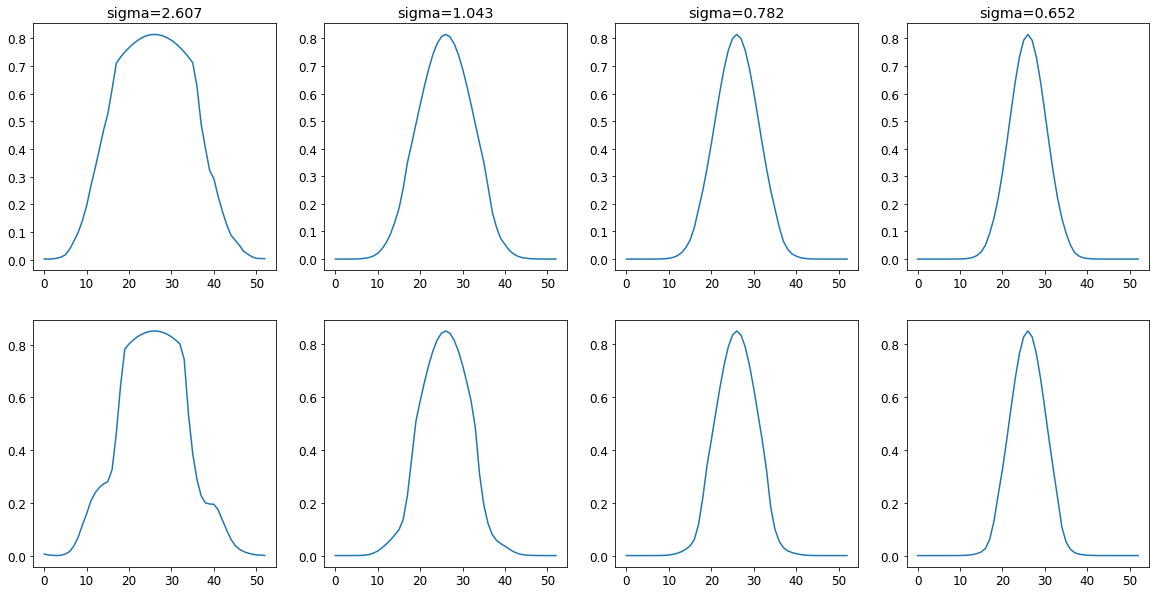

In [157]:
fig, ax = subplots(2, 4, figsize=(20, 10))
for i, EW_apodized in enumerate(NF_EW_apodized):
    EW_slice = EW_apodized[:,slice_index]
    ax[0][i].plot(np.abs(EW_slice))
    ax[0][i].set_title(f"sigma={sigmas[i]:.3f}")
for i, NS_apodized in enumerate(NF_NS_apodized):
    NS_slice = NS_apodized[:,slice_index]
    ax[1][i].plot(np.abs(NS_slice))

<ipython-input-158-b58947800852>:3: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm1=ax[0][i].pcolormesh(x, y, EW_apodized.real)
<ipython-input-158-b58947800852>:4: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm2=ax[1][i].pcolormesh(x, y, EW_apodized.imag)
<ipython-input-158-b58947800852>:11: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals 

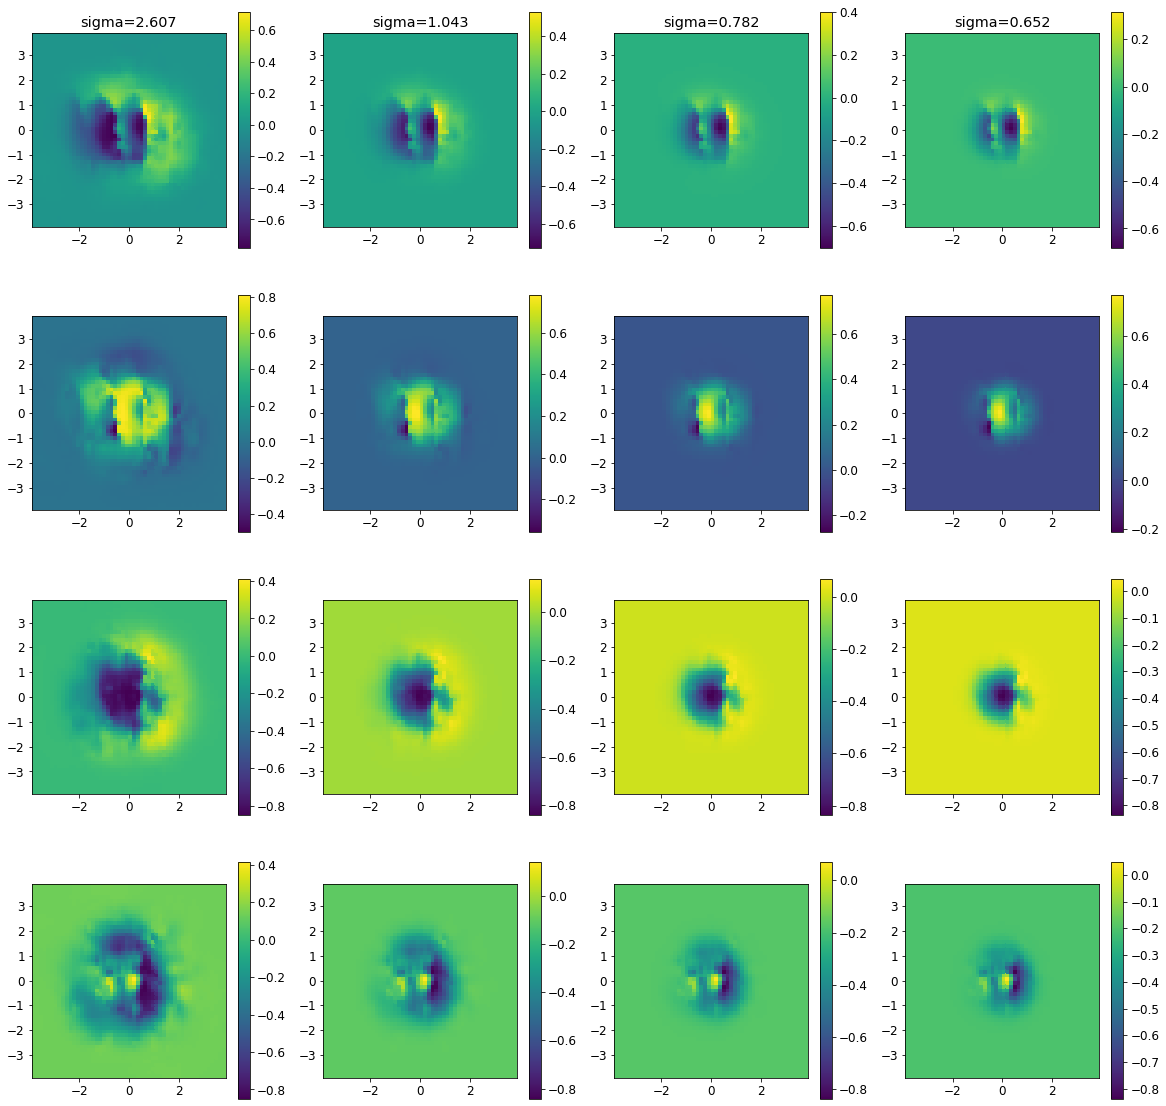

In [158]:
fig,ax=subplots(4,4,figsize=(20,20))
for i, EW_apodized in enumerate(NF_EW_apodized):
    pcm1=ax[0][i].pcolormesh(x, y, EW_apodized.real)
    pcm2=ax[1][i].pcolormesh(x, y, EW_apodized.imag)
    ax[0][i].set_aspect('equal')
    ax[1][i].set_aspect('equal')
    colorbar(mappable=pcm1, ax=ax[0][i])
    colorbar(mappable=pcm2, ax=ax[1][i])
    ax[0][i].set_title(f"sigma={sigmas[i]:.3f}")
for i, NS_apodized in enumerate(NF_NS_apodized):
    pcm1=ax[2][i].pcolormesh(x, y, NS_apodized.real)
    pcm2=ax[3][i].pcolormesh(x, y, NS_apodized.imag)
    ax[2][i].set_aspect('equal')
    ax[3][i].set_aspect('equal')
    colorbar(mappable=pcm1, ax=ax[2][i])
    colorbar(mappable=pcm1, ax=ax[3][i])

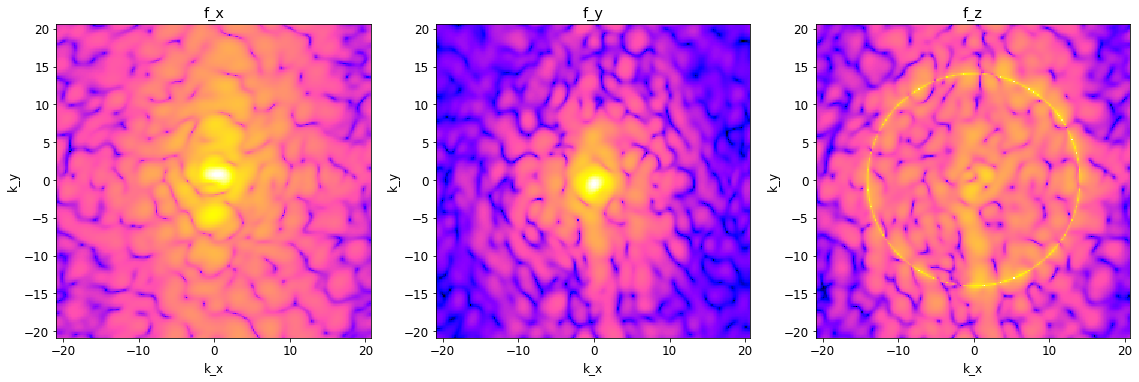

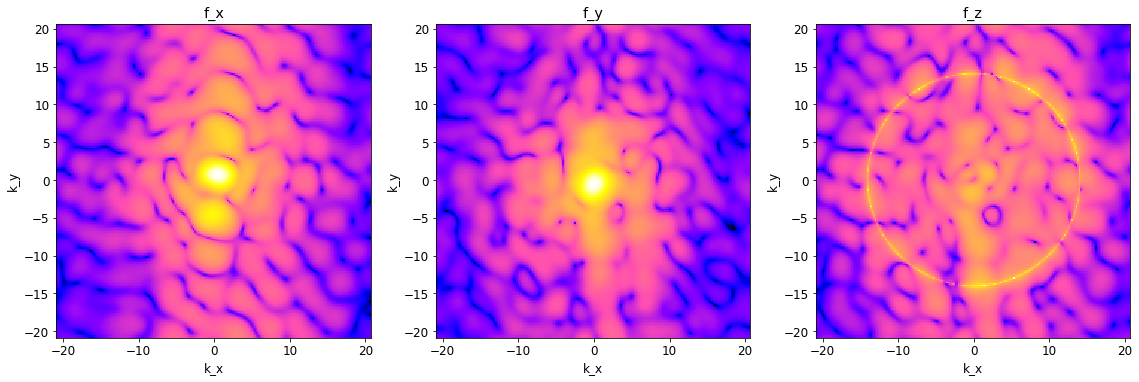

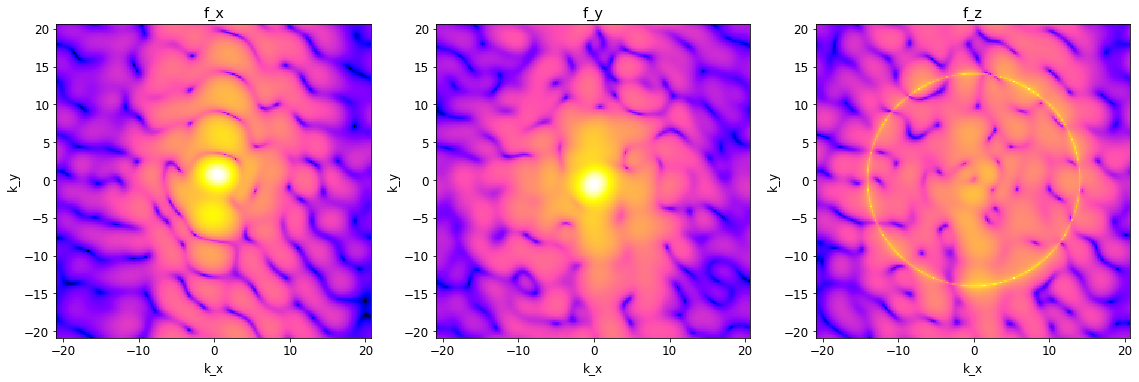

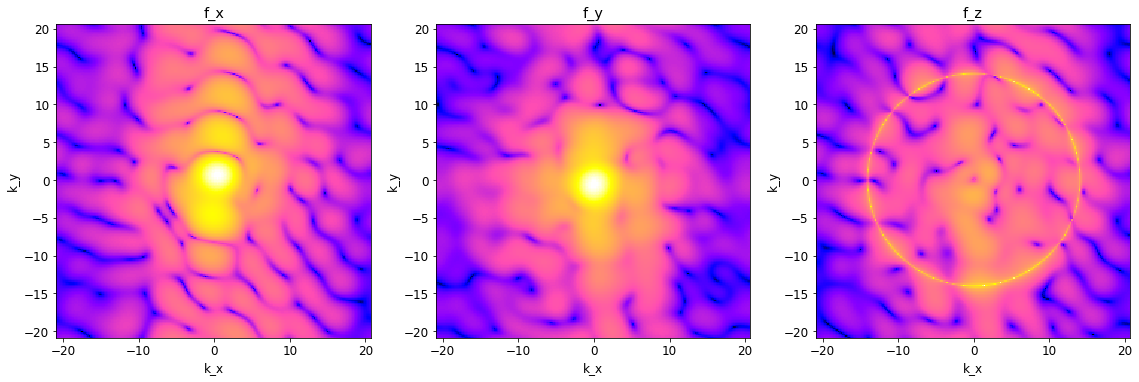

In [191]:
Etheta_array = np.empty((len(sigmas), phi.shape[0], theta.shape[1]),dtype=complex)
Ephi_array = np.empty((len(sigmas), phi.shape[0], theta.shape[1]),dtype=complex)
for i in range(len(sigmas)):
    FourierSpace=nf.NFtoFourier(NF_EW_apodized[i,:,:],NF_NS_apodized[i,:,:],k_X_Rectangular,k_Y_Rectangular,k0,plotFourier=True)
    [Etheta,Ephi]=nf.FouriertoFF(FourierSpace[0],FourierSpace[1],FourierSpace[2],theta,phi,k_X_Rectangular,k_Y_Rectangular,k0,FFOutputs=False)
    Etheta_array[i,:,:] = Etheta
    Ephi_array[i,:,:] = Ephi

<ipython-input-192-bb28eaf7a6f4>:3: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax[0][i].pcolormesh(phi, theta, 20*np.log10(np.abs(E_theta_ap)), cmap='gnuplot2')
<ipython-input-192-bb28eaf7a6f4>:7: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax[1][i].pcolormesh(phi, theta, 20*np.log10(np.abs(E_phi_ap)), cmap='gnuplot2')


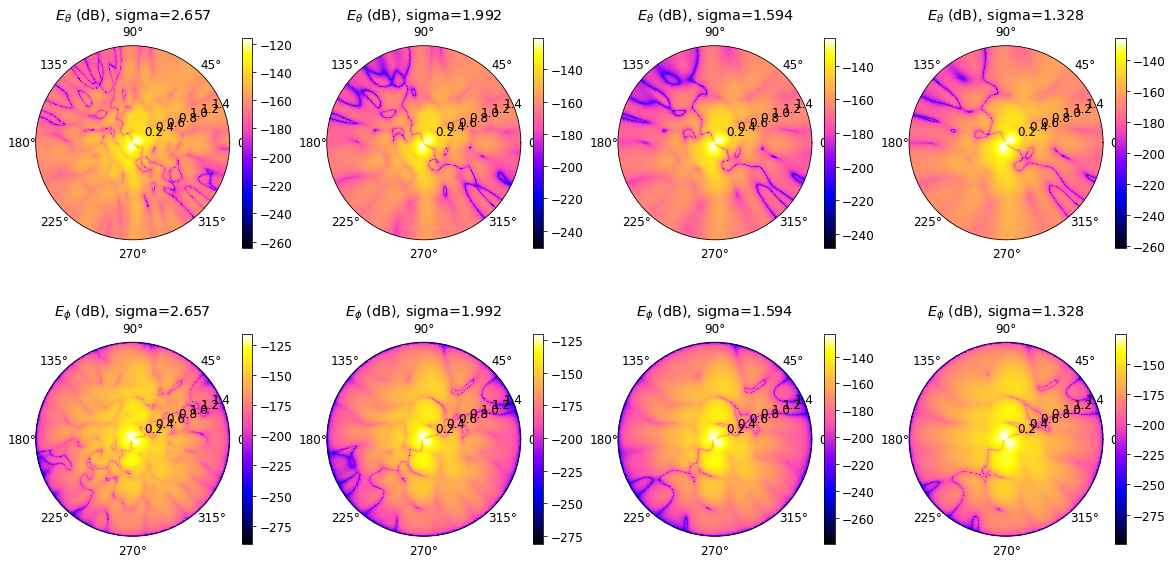

In [192]:
fig, ax = subplots(2, 4, figsize=(20,10),subplot_kw={'polar': True})
for i, E_theta_ap  in enumerate(Etheta_array):
    pcm = ax[0][i].pcolormesh(phi, theta, 20*np.log10(np.abs(E_theta_ap)), cmap='gnuplot2')
    colorbar(mappable=pcm, ax = ax[0][i],shrink=0.85)
    ax[0][i].set_title(fr"$E_{{\theta}}$ (dB), sigma={sigmas[i]:.3f}")
for i, E_phi_ap in enumerate(Ephi_array):
    pcm = ax[1][i].pcolormesh(phi, theta, 20*np.log10(np.abs(E_phi_ap)), cmap='gnuplot2')
    colorbar(mappable=pcm, ax = ax[1][i],shrink=0.85)
    ax[1][i].set_title(fr"$E_{{\phi}}$ (dB), sigma={sigmas[i]:.3f}")
# ax = subplot(1, 2, 1, projection='polar')
# pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
# colorbar(mappable = pcm,shrink = 0.3)
# ax.set_title(r'$E_{\theta}$ (dB)')
# ax.set_theta_offset(np.pi/2.0)
# ax = subplot(1, 2, 2, projection='polar')
# pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Ephi)),cmap='gnuplot2')
# colorbar(mappable = pcm,shrink = 0.3)
# ax.set_title(r'$E_{\phi}$ (dB)')
# ax.set_theta_offset(np.pi/2.0)

## Transforming the data--no apodization

/home/am3674/NF2FF_WL/NF2FF.py:92: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax1.pcolormesh(kx_grid,ky_grid,fx_magnitude,cmap='gnuplot2',norm=LogNorm())
/home/am3674/NF2FF_WL/NF2FF.py:93: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax2.pcolormesh(kx_grid,ky_grid,fy_magnitude,cmap='gnuplot2',norm=LogNorm())
/home/am3674/NF2FF_WL/NF2FF.py:94: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3. 

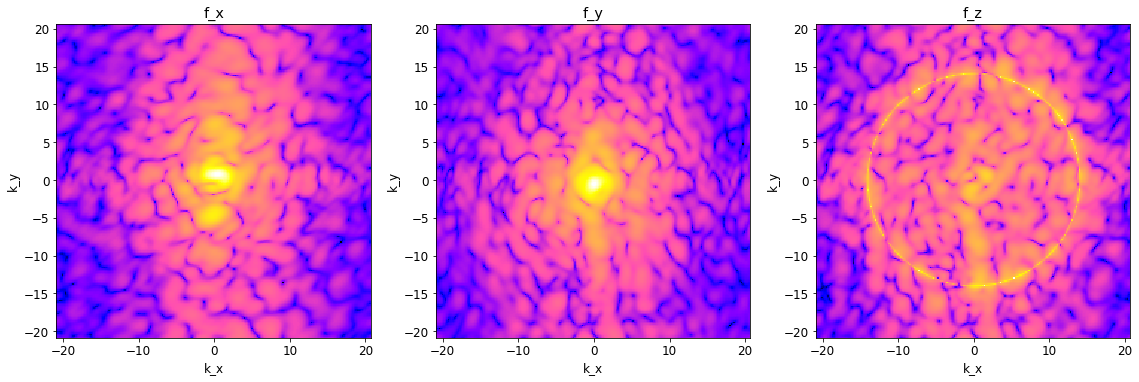

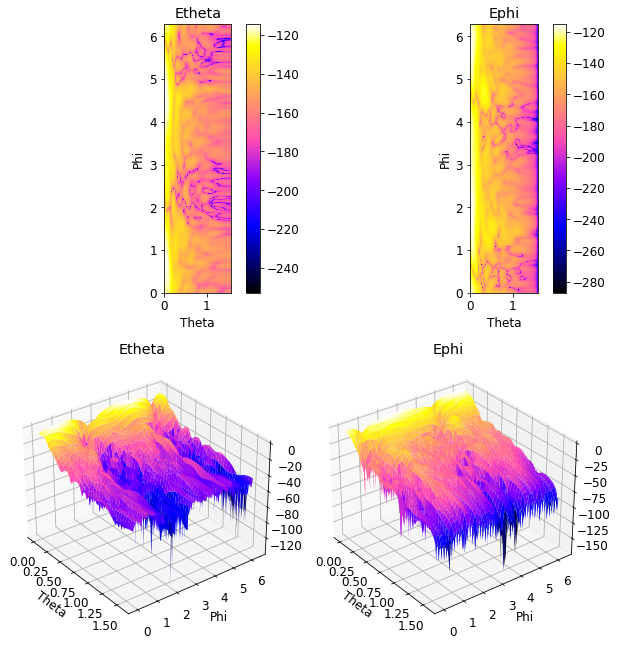

In [186]:
FourierSpace=nf.NFtoFourier(NF_EW_Complex,NF_NS_Complex,k_X_Rectangular,k_Y_Rectangular,k0,plotFourier=True)
[Etheta_noap,Ephi_noap]=nf.FouriertoFF(FourierSpace[0],FourierSpace[1],FourierSpace[2],theta,phi,k_X_Rectangular,k_Y_Rectangular,k0,FFOutputs=True)

<ipython-input-188-5f4045806d89>:3: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Etheta_noap)),cmap='gnuplot2')
<ipython-input-188-5f4045806d89>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Ephi_noap)),cmap='gnuplot2')


Text(0.5, 1.0, '$E_{\\phi}$ (dB)')

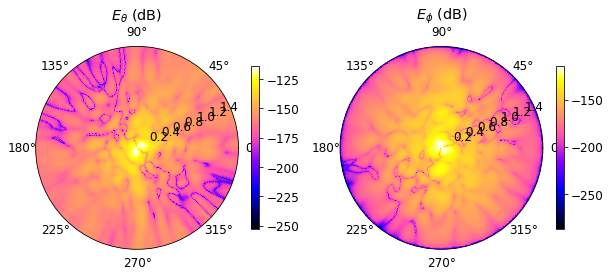

In [188]:
fig = figure(figsize=(10,10))
ax = subplot(1, 2, 1, projection='polar')
pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Etheta_noap)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$ (dB)')
# ax.set_theta_offset(np.pi/2.0)
ax = subplot(1, 2, 2, projection='polar')
pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Ephi_noap)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')
# ax.set_theta_offset(np.pi/2.0)

## Experiment with flat-topped Gaussian

In [175]:
from scipy import signal

# creating a bunch of different apodizations
list_of_intervals = np.array([3, 4, 5, 6])
x_range = len(NF_x_vector)
point_sigmas = x_range/list_of_intervals
print(point_sigmas)
x_spacing = NF_x_vector[1] - NF_x_vector[0]
sigmas = point_sigmas*x_spacing
flat_Gaussian_windows = np.empty((len(point_sigmas), len(NF_x_vector), len(NF_y_vector)))
for i, sigma in enumerate(point_sigmas):
    flat_Gaussian_1D = signal.general_gaussian(len(NF_x_vector),6,sigma)
    flat_Gaussian_windows[i, :, :] = np.outer(flat_Gaussian_1D,flat_Gaussian_1D)

[17.66666667 13.25       10.6         8.83333333]


In [176]:
print(flat_Gaussian_windows.shape)

(4, 53, 53)


<ipython-input-177-ea7094cbd6cb>:4: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm=ax[i].pcolormesh(NF_x, NF_y, Gaussian_window)


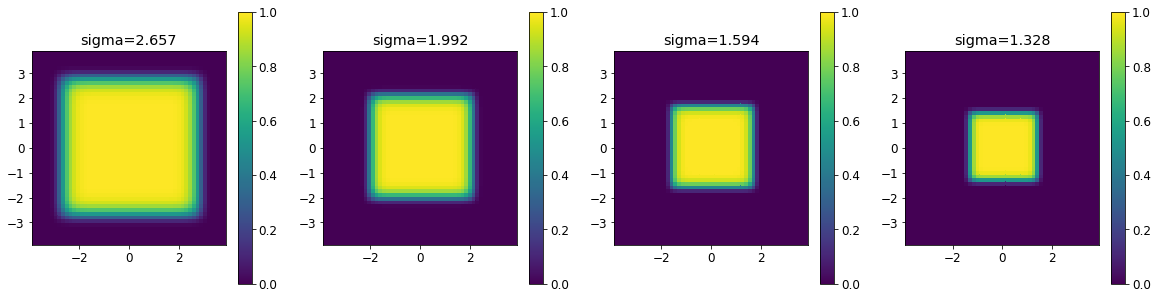

In [177]:
# checking by plotting
fig, ax = subplots(1, 4, figsize=(20, 10))
for i, Gaussian_window in enumerate(flat_Gaussian_windows):
    pcm=ax[i].pcolormesh(NF_x, NF_y, Gaussian_window)
    ax[i].set_aspect('equal')
    colorbar(mappable=pcm, ax=ax[i],shrink=0.5)
    ax[i].set_title(f"sigma={sigmas[i]:.3f}")

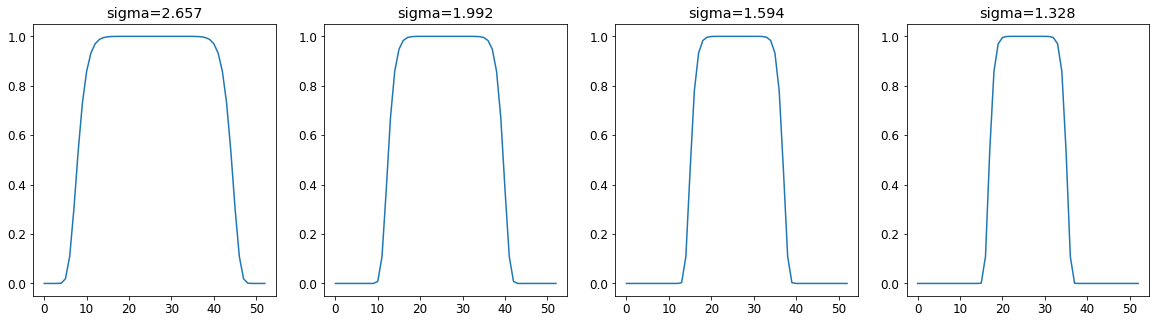

In [181]:
# plotting the slices
fig, ax = subplots(1, 4, figsize=(20, 5))
for i, window in enumerate(flat_Gaussian_windows):
    window_slice = window[:,slice_index]
    ax[i].plot(np.abs(window_slice))
    ax[i].set_title(f"sigma={sigmas[i]:.3f}")

In [182]:
# modulating the function
NF_EW_flat_apodized = NF_EW_Complex*flat_Gaussian_windows
NF_NS_flat_apodized = NF_NS_Complex*flat_Gaussian_windows

<ipython-input-183-71224f4cbf3c>:3: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm1=ax[0][i].pcolormesh(x, y, np.abs(EW_apodized))
<ipython-input-183-71224f4cbf3c>:4: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm2=ax[1][i].pcolormesh(x, y, np.angle(EW_apodized))
<ipython-input-183-71224f4cbf3c>:11: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadril

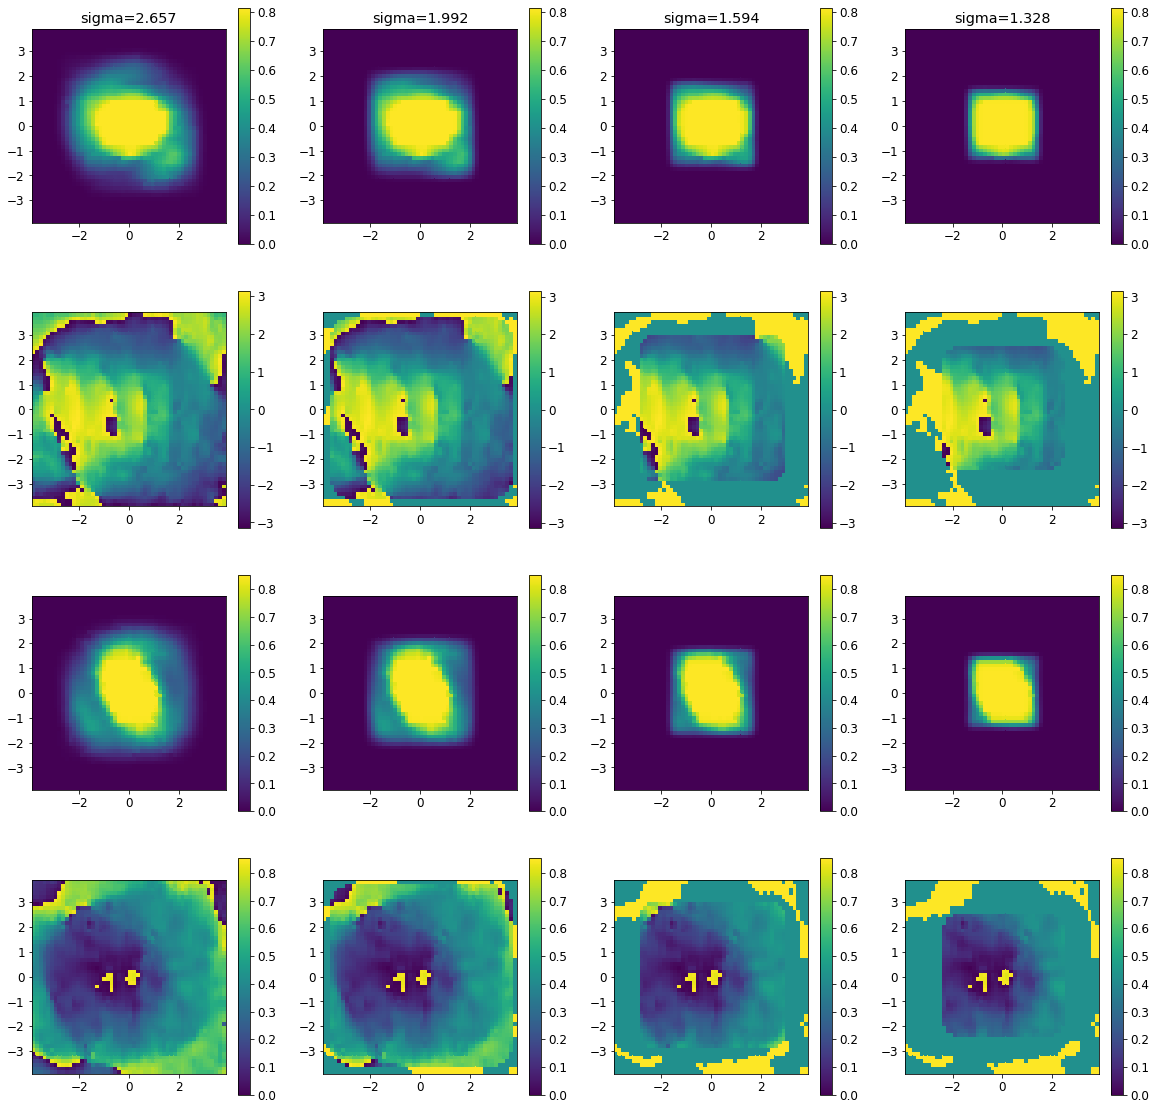

In [183]:
fig,ax=subplots(4,4,figsize=(20,20))
for i, EW_apodized in enumerate(NF_EW_flat_apodized):
    pcm1=ax[0][i].pcolormesh(x, y, np.abs(EW_apodized))
    pcm2=ax[1][i].pcolormesh(x, y, np.angle(EW_apodized))
    ax[0][i].set_aspect('equal')
    ax[1][i].set_aspect('equal')
    colorbar(mappable=pcm1, ax=ax[0][i])
    colorbar(mappable=pcm2, ax=ax[1][i])
    ax[0][i].set_title(f"sigma={sigmas[i]:.3f}")
for i, NS_apodized in enumerate(NF_NS_flat_apodized):
    pcm1=ax[2][i].pcolormesh(x, y, np.abs(NS_apodized))
    pcm2=ax[3][i].pcolormesh(x, y, np.angle(NS_apodized))
    ax[2][i].set_aspect('equal')
    ax[3][i].set_aspect('equal')
    colorbar(mappable=pcm1, ax=ax[2][i])
    colorbar(mappable=pcm1, ax=ax[3][i])

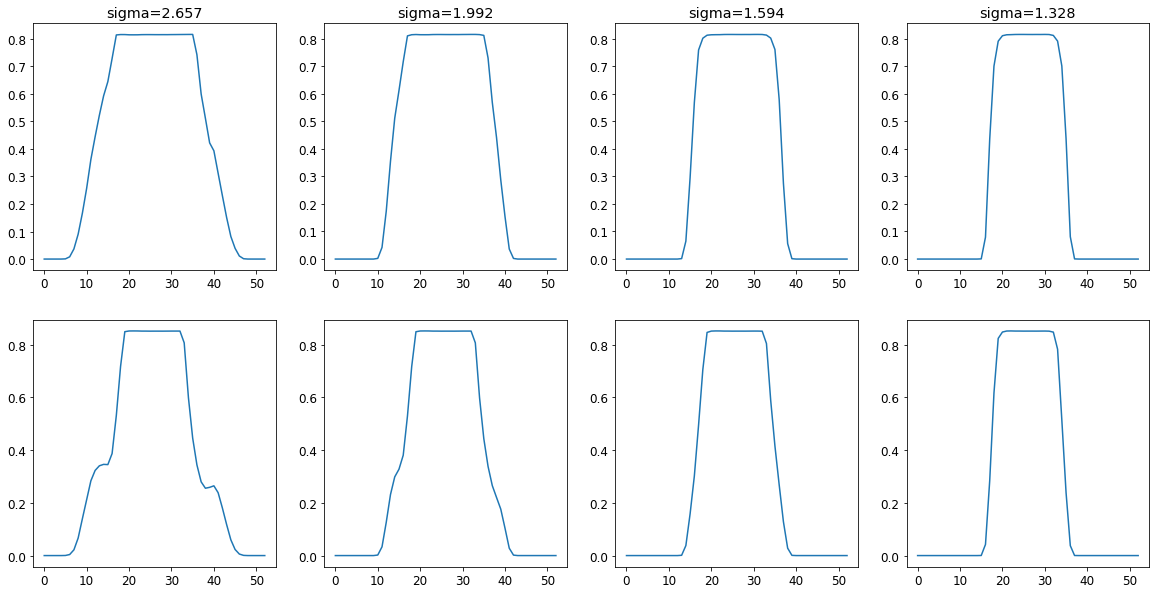

In [193]:
# plotting slice of the modulated signal
fig, ax = subplots(2, 4, figsize=(20, 10))
for i, EW_apodized in enumerate(NF_EW_flat_apodized):
    EW_slice = EW_apodized[:,slice_index]
    ax[0][i].plot(np.abs(EW_slice))
    ax[0][i].set_title(f"sigma={sigmas[i]:.3f}")
for i, NS_apodized in enumerate(NF_NS_flat_apodized):
    NS_slice = NS_apodized[:,slice_index]
    ax[1][i].plot(np.abs(NS_slice))

<ipython-input-194-cd07d187723e>:4: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm1=ax[0][i].pcolormesh(x, y, EW_apodized.real)
<ipython-input-194-cd07d187723e>:5: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm2=ax[1][i].pcolormesh(x, y, EW_apodized.imag)
<ipython-input-194-cd07d187723e>:12: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals 

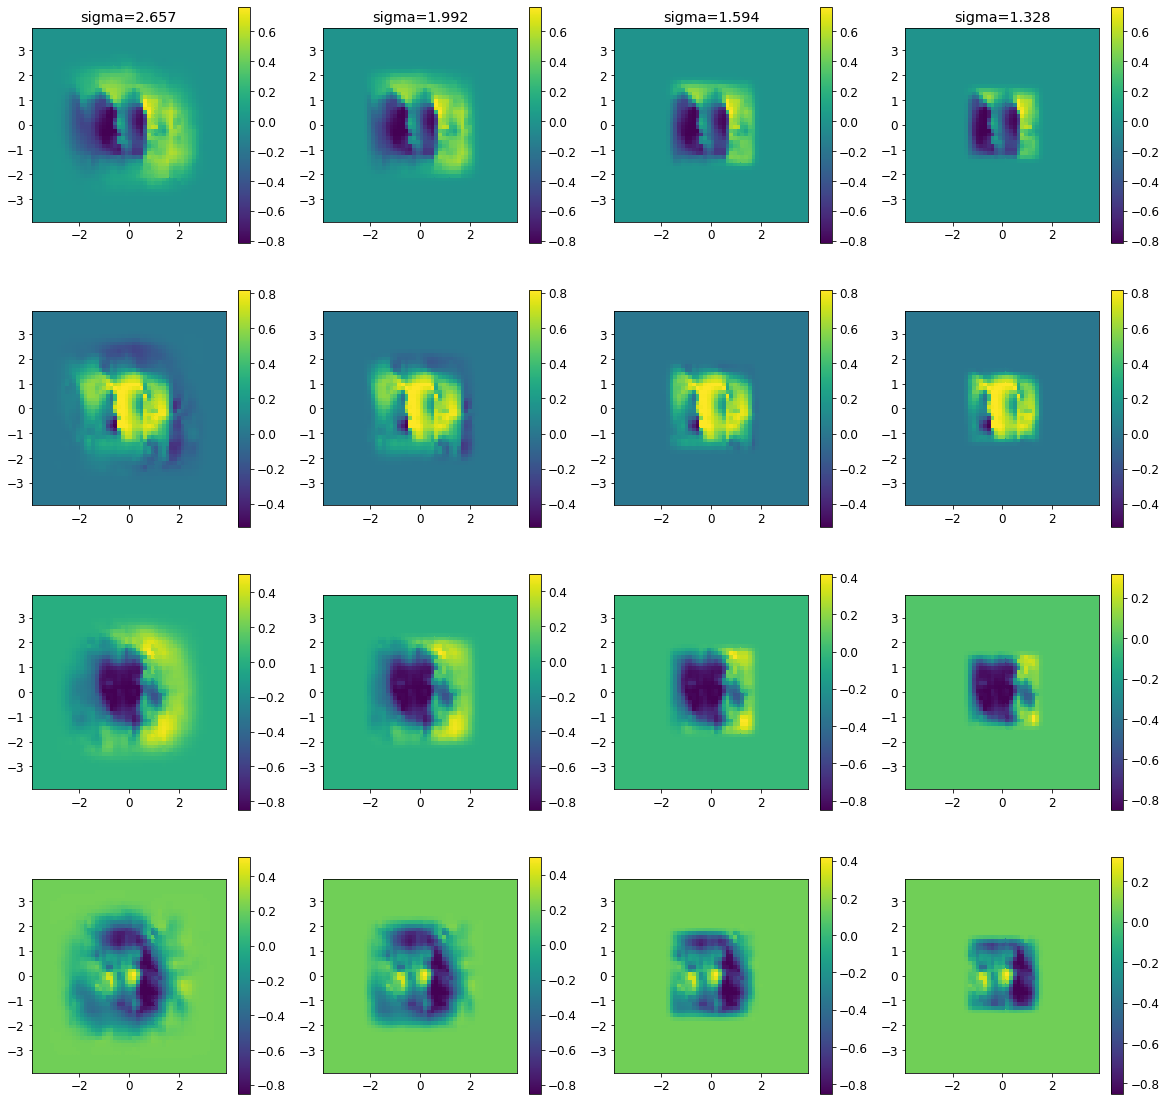

In [194]:
# plotting real, imaginary components of the signal modulated by a flat Gaussian
fig,ax=subplots(4,4,figsize=(20,20))
for i, EW_apodized in enumerate(NF_EW_flat_apodized):
    pcm1=ax[0][i].pcolormesh(x, y, EW_apodized.real)
    pcm2=ax[1][i].pcolormesh(x, y, EW_apodized.imag)
    ax[0][i].set_aspect('equal')
    ax[1][i].set_aspect('equal')
    colorbar(mappable=pcm1, ax=ax[0][i])
    colorbar(mappable=pcm2, ax=ax[1][i])
    ax[0][i].set_title(f"sigma={sigmas[i]:.3f}")
for i, NS_apodized in enumerate(NF_NS_flat_apodized):
    pcm1=ax[2][i].pcolormesh(x, y, NS_apodized.real)
    pcm2=ax[3][i].pcolormesh(x, y, NS_apodized.imag)
    ax[2][i].set_aspect('equal')
    ax[3][i].set_aspect('equal')
    colorbar(mappable=pcm1, ax=ax[2][i])
    colorbar(mappable=pcm1, ax=ax[3][i])

/home/am3674/NF2FF_WL/NF2FF.py:92: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax1.pcolormesh(kx_grid,ky_grid,fx_magnitude,cmap='gnuplot2',norm=LogNorm())
/home/am3674/NF2FF_WL/NF2FF.py:93: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax2.pcolormesh(kx_grid,ky_grid,fy_magnitude,cmap='gnuplot2',norm=LogNorm())
/home/am3674/NF2FF_WL/NF2FF.py:94: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3. 

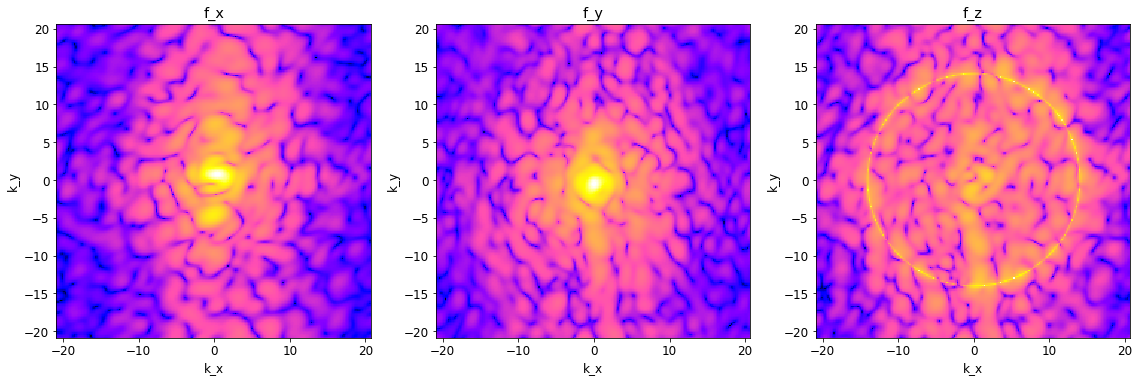

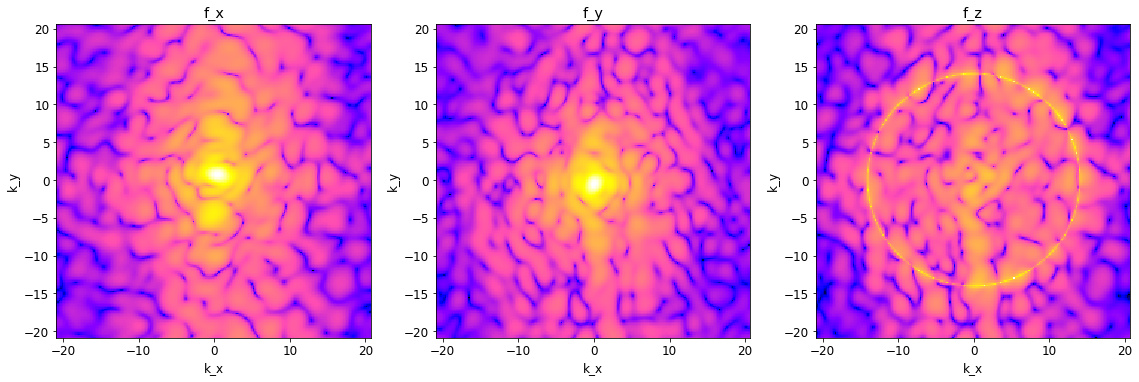

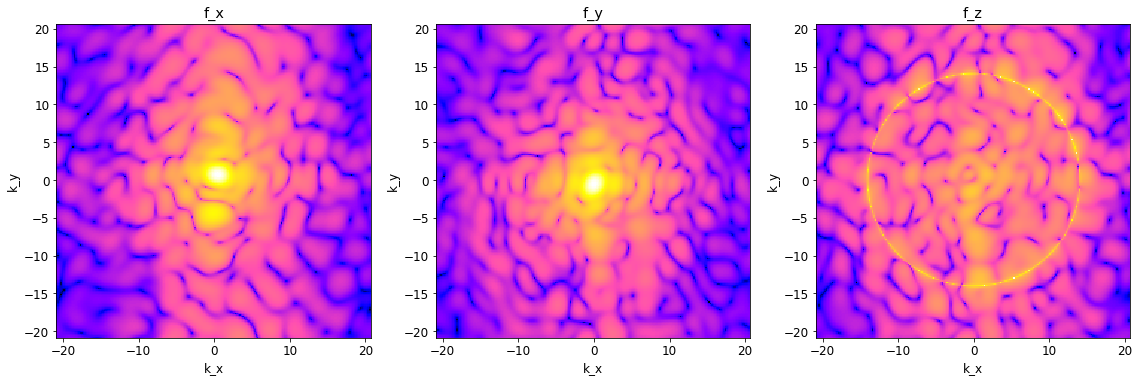

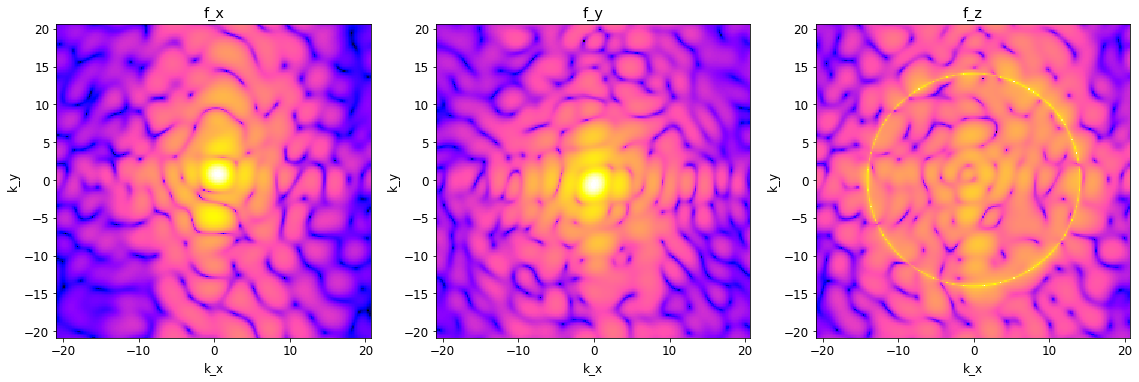

In [195]:
Etheta_flat_Gauss = np.empty((len(sigmas), phi.shape[0], theta.shape[1]),dtype=complex)
Ephi_flat_Gauss = np.empty((len(sigmas), phi.shape[0], theta.shape[1]),dtype=complex)
for i in range(len(sigmas)):
    FourierSpace=nf.NFtoFourier(NF_EW_flat_apodized[i,:,:],NF_NS_flat_apodized[i,:,:],k_X_Rectangular,k_Y_Rectangular,k0,plotFourier=True)
    [Etheta,Ephi]=nf.FouriertoFF(FourierSpace[0],FourierSpace[1],FourierSpace[2],theta,phi,k_X_Rectangular,k_Y_Rectangular,k0,FFOutputs=False)
    Etheta_flat_Gauss[i,:,:] = Etheta
    Ephi_flat_Gauss[i,:,:] = Ephi

<ipython-input-196-2d1f79d88fc1>:3: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax[0][i].pcolormesh(phi, theta, 20*np.log10(np.abs(E_theta_ap)), cmap='gnuplot2')
<ipython-input-196-2d1f79d88fc1>:7: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax[1][i].pcolormesh(phi, theta, 20*np.log10(np.abs(E_phi_ap)), cmap='gnuplot2')


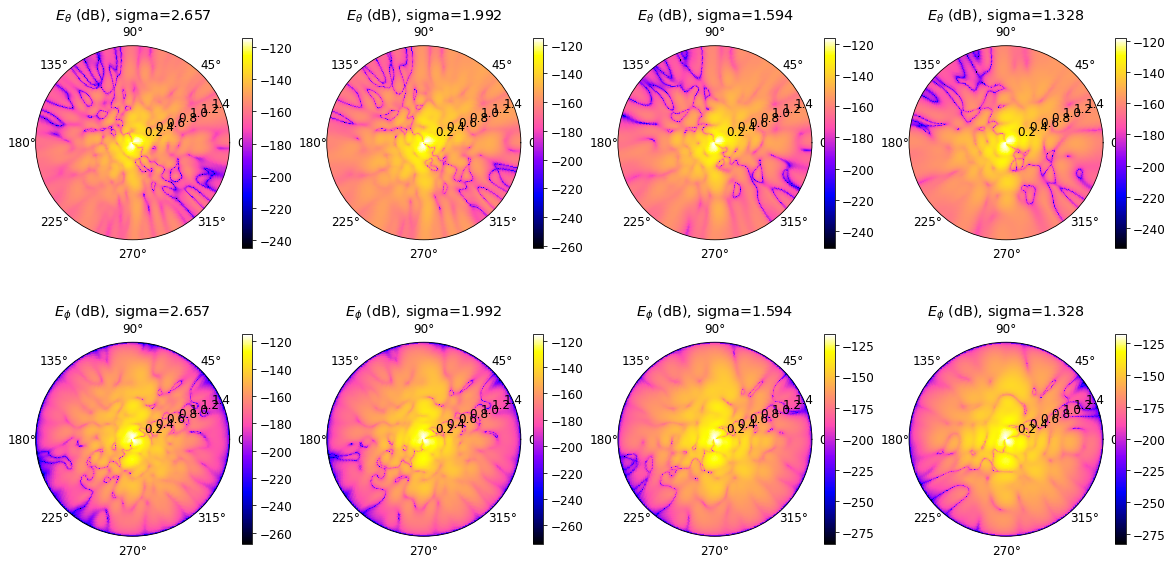

In [196]:
fig, ax = subplots(2, 4, figsize=(20,10),subplot_kw={'polar': True})
for i, E_theta_ap  in enumerate(Etheta_flat_Gauss):
    pcm = ax[0][i].pcolormesh(phi, theta, 20*np.log10(np.abs(E_theta_ap)), cmap='gnuplot2')
    colorbar(mappable=pcm, ax = ax[0][i],shrink=0.85)
    ax[0][i].set_title(fr"$E_{{\theta}}$ (dB), sigma={sigmas[i]:.3f}")
for i, E_phi_ap in enumerate(Ephi_flat_Gauss):
    pcm = ax[1][i].pcolormesh(phi, theta, 20*np.log10(np.abs(E_phi_ap)), cmap='gnuplot2')
    colorbar(mappable=pcm, ax = ax[1][i],shrink=0.85)
    ax[1][i].set_title(fr"$E_{{\phi}}$ (dB), sigma={sigmas[i]:.3f}")
# ax = subplot(1, 2, 1, projection='polar')
# pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
# colorbar(mappable = pcm,shrink = 0.3)
# ax.set_title(r'$E_{\theta}$ (dB)')
# ax.set_theta_offset(np.pi/2.0)
# ax = subplot(1, 2, 2, projection='polar')
# pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Ephi)),cmap='gnuplot2')
# colorbar(mappable = pcm,shrink = 0.3)
# ax.set_title(r'$E_{\phi}$ (dB)')
# ax.set_theta_offset(np.pi/2.0)

## Experiment with zero-padding first--this may be terrible and unadvisable

In [199]:
# zero-padding the NF_NS and NF_EW arrays with about 15 additional zeros on either end
num_added = 15
NF_NS_Complex_padded = np.pad(NF_NS_Complex, num_added)
NF_EW_Complex_padded = np.pad(NF_EW_Complex, num_added)

In [201]:
# adjusting the x and y-values
dx = NF_x_vector[1] - NF_x_vector[0]
dy = NF_y_vector[1] - NF_y_vector[0]
x_beginning = np.linspace(NF_x_vector[0] - num_added*dx, NF_x_vector[0] - dx, num_added)
x_end = np.linspace(NF_x_vector[-1] + num_added, NF_x_vector[-1] + num_added*dx, num_added)
y_beginning = np.linspace(NF_y_vector[0] - num_added*dy, NF_y_vector[0] - dy, num_added)
y_end = np.linspace(NF_y_vector[-1] + num_added, NF_y_vector[-1] + num_added*dy, num_added)

print(x_beginning.shape)
print(x_end.shape)
print(y_beginning.shape)
print(y_end.shape)
print(NF_x_vector.shape)
print(NF_y_vector.shape)

# concatenate into big x, y vectors
x_padded = np.concatenate((x_beginning,NF_x_vector,x_end))
y_padded = np.concatenate((y_beginning,NF_y_vector,y_end))

(15,)
(15,)
(15,)
(15,)
(53,)
(53,)


ValueError: need at least one array to concatenate

TypeError: Dimensions of C (83, 83) are incompatible with X (53) and/or Y (53); see help(pcolormesh)

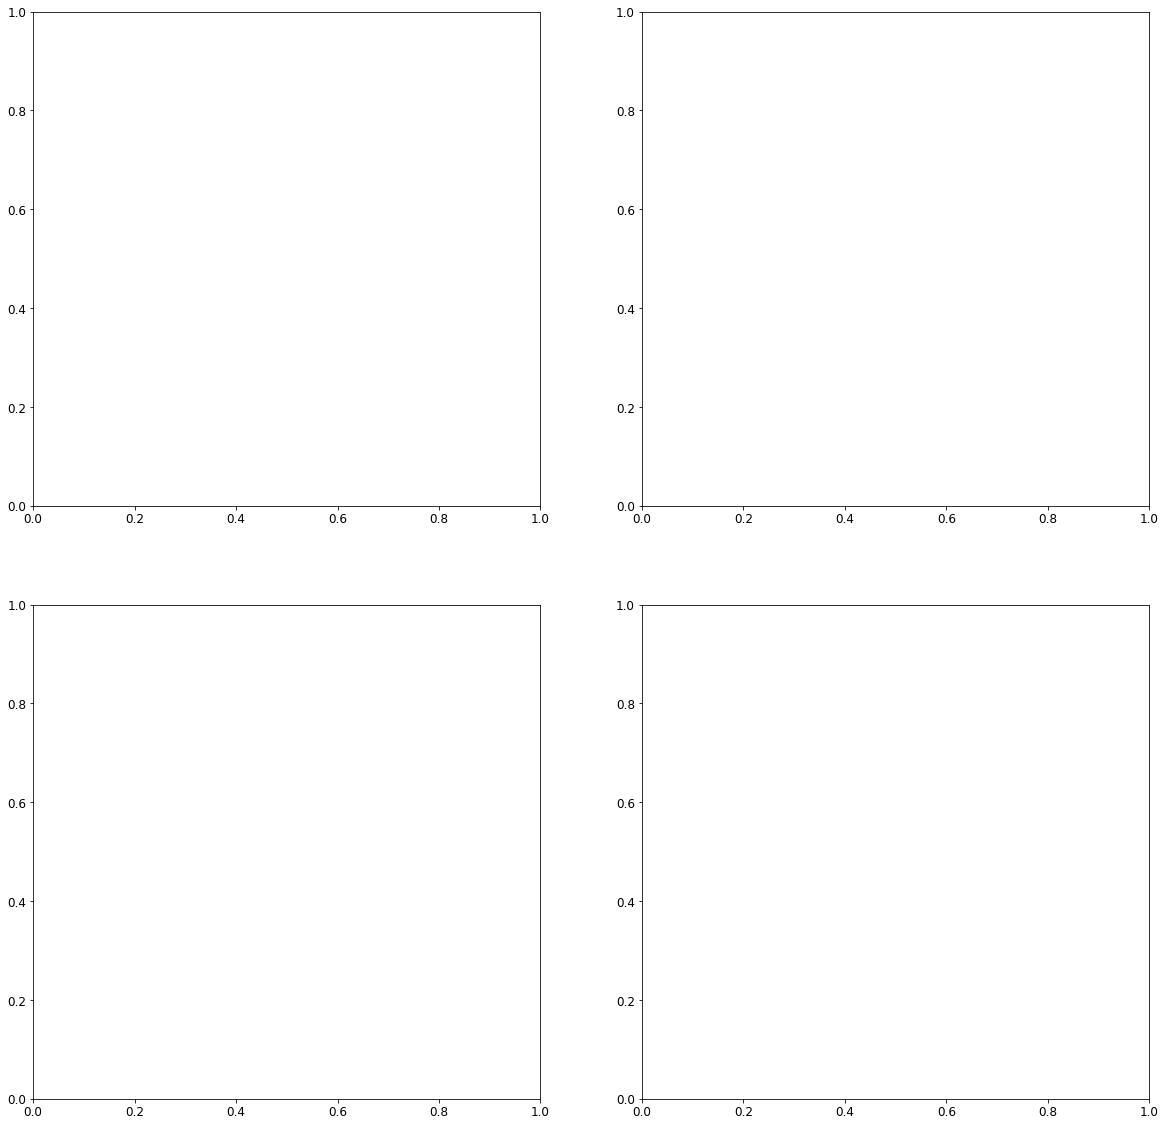

In [198]:
fig,ax=subplots(2,2,figsize=(20,20))
pcm1 = ax[0][0].pcolormesh(x,y,np.abs(NF_EW_Complex_padded))
ax[0][0].set_title('NF EW Pol Amplitude')
pcm2 = ax[0][1].pcolormesh(x,y,np.abs(NF_NS_Complex_padded))
ax[0][1].set_title('NF NS Pol Amplitude')
pcm3 = ax[1][0].pcolormesh(x,y,np.angle(NF_EW_Complex_padded))
ax[1][0].set_title('NF EW Pol Phase')
pcm4 = ax[1][1].pcolormesh(x,y,np.angle(NF_NS_Complex_padded))
ax[1][1].set_title('NF NS Pol Phase')
pcms = [[pcm1, pcm2], [pcm3, pcm4]]
for i, axis_set in enumerate(ax):
    for i2, a in enumerate(axis_set):
        a.set_aspect('equal')
        colorbar(mappable=pcms[i][i2],ax=a)

<ipython-input-42-e7fbcdf550d6>:3: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi[:,:],theta[:,:],20*np.log10(np.abs(Etheta[:,:])),cmap='gnuplot2')
<ipython-input-42-e7fbcdf550d6>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi[:,:],theta[:,:],20*np.log10(np.abs(Ephi[:,:])),cmap='gnuplot2')


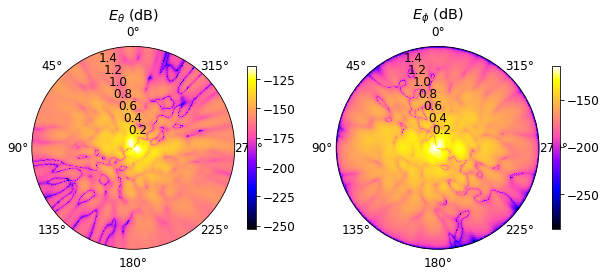

In [42]:
fig = figure(figsize=(10,10))
ax = subplot(1, 2, 1, projection='polar')
pcm = pcolormesh(phi[:,:],theta[:,:],20*np.log10(np.abs(Etheta[:,:])),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$ (dB)')
ax.set_theta_offset(np.pi/2.0)
ax = subplot(1, 2, 2, projection='polar')
pcm = pcolormesh(phi[:,:],theta[:,:],20*np.log10(np.abs(Ephi[:,:])),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')
ax.set_theta_offset(np.pi/2.0)

<ipython-input-43-35e28f44a76a>:4: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi[:,:],theta[:,:],np.abs(Etheta[:,:]),cmap='gnuplot2')
<ipython-input-43-35e28f44a76a>:9: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi[:,:],theta[:,:],np.abs(Ephi[:,:]),cmap='gnuplot2')


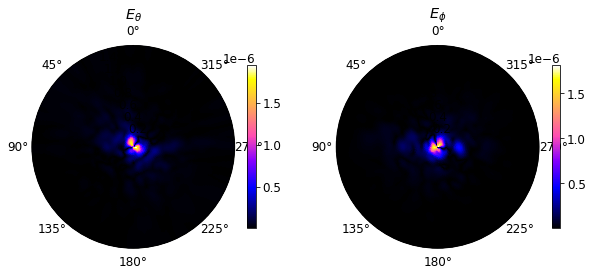

In [43]:
# the same, without log scale
fig = figure(figsize=(10,10))
ax = subplot(1, 2, 1, projection='polar')
pcm = pcolormesh(phi[:,:],theta[:,:],np.abs(Etheta[:,:]),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$')
ax.set_theta_offset(np.pi/2.0)
ax = subplot(1, 2, 2, projection='polar')
pcm = pcolormesh(phi[:,:],theta[:,:],np.abs(Ephi[:,:]),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$')
ax.set_theta_offset(np.pi/2.0)

<ipython-input-54-c70c49f5550e>:3: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
<ipython-input-54-c70c49f5550e>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Ephi)),cmap='gnuplot2')


(0.0, 1.0)

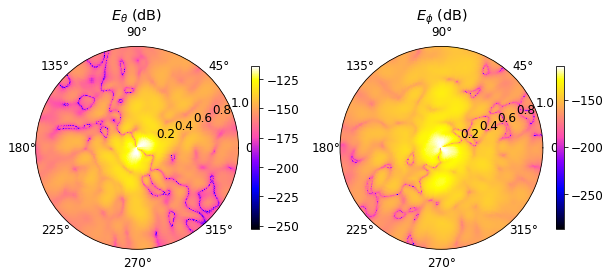

In [54]:
# the difference with this 1 is that the y coordinates (theta) is limited from 0 to 1 (I don't think we want this but I did it)
fig = figure(figsize=(10,10))
ax = subplot(1, 2, 1, projection='polar')
pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_ylim(0,1)
ax.set_title(r'$E_{\theta}$ (dB)')
ax = subplot(1, 2, 2, projection='polar')
pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Ephi)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')
ax.set_ylim(0,1)

[[0.   0.   0.   ... 0.   0.   0.  ]
 [0.01 0.01 0.01 ... 0.01 0.01 0.01]
 [0.02 0.02 0.02 ... 0.02 0.02 0.02]
 ...
 [6.27 6.27 6.27 ... 6.27 6.27 6.27]
 [6.28 6.28 6.28 ... 6.28 6.28 6.28]
 [6.29 6.29 6.29 ... 6.29 6.29 6.29]]


<ipython-input-45-68835ef128d3>:5: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,np.abs(np.sin(theta)),20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
<ipython-input-45-68835ef128d3>:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,np.abs(np.sin(theta)),20*np.log10(np.abs(Ephi)),cmap='gnuplot2')


(0.0, 1.0)

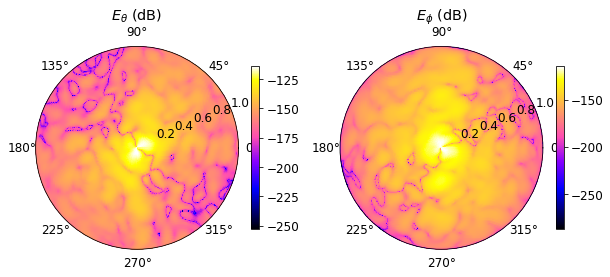

In [45]:
print (phi)
# trying to project from polar onto the xy plane
fig = figure(figsize=(10,10))
ax = subplot(1, 2, 1, projection='polar')
pcm = pcolormesh(phi,np.abs(np.sin(theta)),20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$ (dB)')
ax.set_ylim(0,1)
ax = subplot(1, 2, 2, projection='polar')
pcm = pcolormesh(phi,np.abs(np.sin(theta)),20*np.log10(np.abs(Ephi)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')
ax.set_ylim(0,1)

[]

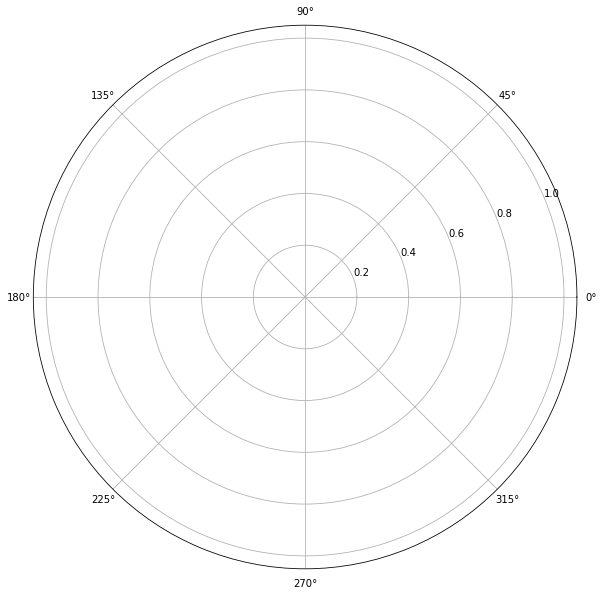

In [139]:
fig = figure(figsize = (10,10))
ax = subplot(1,1,1,projection = 'polar')
data = np.ones(len(theta))
polar()

/home/am3674/anaconda3/lib/python3.8/site-packages/numpy/core/_asarray.py:171: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order, subok=True)


Text(0.5, 0.92, '$E_{\\phi}$ (dB)')

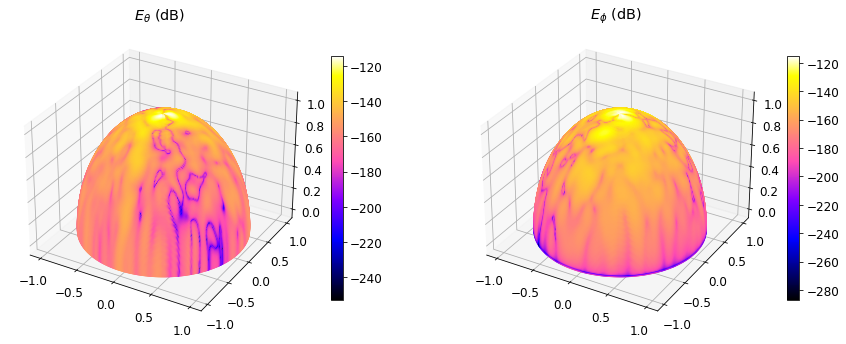

In [46]:
fig = figure(figsize=(15,15))
ax = subplot(1,2,1,projection='3d')

# Create the mesh in polar coordinates and compute corresponding Z.
R = Etheta
# Express the mesh in the cartesian system.
X = np.sin(theta)*np.cos(phi)
Y = np.sin(theta)*np.sin(phi)
Z = np.cos(theta)

# Plot the surface.
pcm = ax.scatter(X, Y, zs=Z,c=20*np.log10(Etheta),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$ (dB)')

ax = subplot(1,2,2,projection='3d')

# Create the mesh in polar coordinates and compute corresponding Z.
R = Ephi
# Express the mesh in the cartesian system.
X = np.sin(theta)*np.cos(phi)
Y = np.sin(theta)*np.sin(phi)
Z = np.cos(theta)

# Plot the surface.
pcm = ax.scatter(X, Y, zs=Z,c=20*np.log10(Ephi),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')

/home/am3674/anaconda3/lib/python3.8/site-packages/matplotlib/colors.py:271: ComplexWarning: Casting complex values to real discards the imaginary part
  c = tuple(map(float, c))
/home/am3674/anaconda3/lib/python3.8/site-packages/numpy/core/_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0.5, 0.92, '$E_{\\phi}$ (dB)')

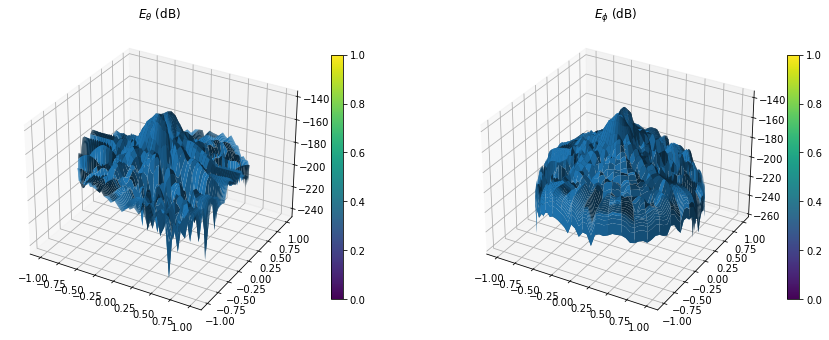

In [141]:
fig = figure(figsize=(15,15))
ax = subplot(1,2,1,projection='3d')

# Create the mesh in polar coordinates and compute corresponding Z.
R = Etheta
# Express the mesh in the cartesian system.
X = np.sin(theta)*np.cos(phi)
Y = np.sin(theta)*np.sin(phi)
Z = np.cos(theta)

# Plot the surface.
pcm = ax.plot_surface(X, Y,20*np.log10(Etheta))
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$ (dB)')

ax = subplot(1,2,2,projection='3d')

# Create the mesh in polar coordinates and compute corresponding Z.
R = Ephi
# Express the mesh in the cartesian system.
X = np.sin(theta)*np.cos(phi)
Y = np.sin(theta)*np.sin(phi)
Z = np.cos(theta)

# Plot the surface.
pcm = ax.plot_surface(X, Y, 20*np.log10(Ephi))
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')